# Enterprise Data Architecture & Reconciliation

**Objective:** Build a scalable Python pipeline for a FinTech Q1–Q4 financial audit using three messy source systems: a historical SQL user database, 100,000 raw server logs, and daily EUR/USD exchange rates.

This notebook implements all four required phases from the supplied capstone brief: advanced SQL, vectorized regex extraction, temporal reconciliation, and CFO dashboard visualizations.

In [1]:
# ===================================================================
# SETUP & CONFIGURATION
# ===================================================================
from pathlib import Path
import sqlite3
import time
import re
import pandas as pd
import matplotlib.pyplot as plt

# Resolve the repository root whether the notebook is opened from
# the repository root or directly from the notebooks/ folder.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent

DB_PATH = PROJECT_ROOT / "data" / "raw" / "enterprise_database.db"
LOG_PATH = PROJECT_ROOT / "data" / "raw" / "server_logs.txt"
FX_PATH = PROJECT_ROOT / "data" / "raw" / "daily_exchange_rates.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "df_final.csv"
DASHBOARD_PATH = PROJECT_ROOT / "dashboard" / "CFO_Financial_Audit_Dashboard.png"

print(f"Project directory: {PROJECT_ROOT}")


Project directory: /mnt/data/enterprise_data_reconciliation_project


In [2]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
# Get the latest record for each user, then keep only users whose
# latest status is Active. ROW_NUMBER() makes the historical status
# logic explicit and reproducible.

sql = """
WITH ranked_users AS (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)
SELECT
    user_id AS User_ID,
    name AS Customer_Name,
    status AS Status,
    updated_at AS Updated_At
FROM ranked_users
WHERE rn = 1
  AND status = 'Active';
"""

start = time.perf_counter()
with sqlite3.connect(DB_PATH) as conn:
    df_active_users = pd.read_sql_query(sql, conn)
sql_time = time.perf_counter() - start

print(f"Active users extracted: {len(df_active_users):,}")
print(f"SQL execution time: {sql_time:.3f} seconds")
df_active_users.head()

Active users extracted: 14,183
SQL execution time: 0.067 seconds


,User_ID,Customer_Name,Status,Updated_At
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


In [3]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================
# Read the raw text as one column. ERROR records are excluded before
# extraction because their payload contains failed_val rather than a
# successful EUR transaction. No row-wise Pandas loops are used.

logs = pd.read_csv(
    LOG_PATH,
    header=None,
    names=['raw_log'],
    skiprows=1,
    dtype='string'
)

info_logs = logs.loc[
    ~logs['raw_log'].str.contains('ERROR', regex=False, na=False),
    'raw_log'
]

pattern = (
    r'\[(?P<Date>\d{4}-\d{2}-\d{2})[^\]]*\]\s+'
    r'(?P<Level>INFO|ERROR).*?payload=\{\"u\":\"(?P<User_ID>[^\"]+)\",\s*'
    r'\"item_code\":\"(?P<Product_ID>[^\"]+)\",\s*'
    r'\"(?P<value_key>eur_val|failed_val)\":(?P<Euro_Value>[\d.]+)\}'
)

start = time.perf_counter()
extracted_data = info_logs.str.extract(pattern)
regex_time = time.perf_counter() - start

extracted_data = (
    extracted_data[['Date', 'User_ID', 'Product_ID', 'Euro_Value']]
    .assign(
        Date=lambda d: pd.to_datetime(d['Date']),
        Euro_Value=lambda d: pd.to_numeric(d['Euro_Value'], errors='coerce')
    )
    .dropna(subset=['Date', 'User_ID', 'Product_ID', 'Euro_Value'])
)

print(f"Raw log rows: {len(logs):,}")
print(f"ERROR rows removed: {len(logs) - len(info_logs):,}")
print(f"Successful transactions extracted: {len(extracted_data):,}")
print(f"Vectorized regex time: {regex_time:.3f} seconds")
extracted_data.head()

Raw log rows: 100,000
ERROR rows removed: 5,098
Successful transactions extracted: 94,902
Vectorized regex time: 0.233 seconds


,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
2,2023-05-09,U-18932,PRD-905,3406.21
3,2023-10-21,U-15882,PRD-284,164.08
4,2023-01-10,U-22781,PRD-665,26.8
5,2023-05-23,U-13348,PRD-589,4964.77


In [4]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================
# The FX source has missing market dates. Sorting by date and using
# forward-fill carries the most recent available market rate into
# subsequent missing dates. This preserves transactions instead of
# losing them through an inner join on the raw FX table.

exchange_rates = pd.read_csv(FX_PATH, parse_dates=['Date'])
exchange_rates = exchange_rates.sort_values('Date').reset_index(drop=True)
exchange_rates['EUR_to_USD'] = exchange_rates['EUR_to_USD'].ffill()

start = time.perf_counter()

df_final = (
    extracted_data
    .merge(exchange_rates, on='Date', how='left', validate='many_to_one')
    .merge(df_active_users, on='User_ID', how='inner', validate='many_to_one')
)

df_final['USD_Revenue'] = df_final['Euro_Value'] * df_final['EUR_to_USD']
df_final['Month'] = df_final['Date'].dt.to_period('M').astype(str)

merge_time = time.perf_counter() - start

# Keep the business-facing columns in a clean order.
df_final = df_final[[
    'Date', 'Month', 'User_ID', 'Customer_Name', 'Product_ID',
    'Euro_Value', 'EUR_to_USD', 'USD_Revenue', 'Status', 'Updated_At'
]].sort_values(['Date', 'User_ID']).reset_index(drop=True)

df_final.to_csv(OUTPUT_PATH, index=False)

print(f"Final reconciled rows: {len(df_final):,}")
print(f"Unique active customers represented: {df_final['User_ID'].nunique():,}")
print(f"Missing FX rates after forward-fill: {df_final['EUR_to_USD'].isna().sum():,}")
print(f"Merge/calculation time: {merge_time:.3f} seconds")
print(f"Saved: {OUTPUT_PATH.name}")
df_final.head()

Final reconciled rows: 53,899
Unique active customers represented: 13,888
Missing FX rates after forward-fill: 0
Merge/calculation time: 0.110 seconds
Saved: df_final.csv


,Date,Month,User_ID,Customer_Name,Product_ID,Euro_Value,EUR_to_USD,USD_Revenue,Status,Updated_At
0,2023-01-01,2023-01,U-00019,User_U-00019,PRD-150,3787.25,1.124836,4260.034034,Active,2023-01-22 14:00:00
1,2023-01-01,2023-01,U-00073,User_U-00073,PRD-391,4443.73,1.124836,4998.466179,Active,2023-01-12 14:00:00
2,2023-01-01,2023-01,U-00276,User_U-00276,PRD-166,4732.06,1.124836,5322.790059,Active,2023-01-21 14:00:00
3,2023-01-01,2023-01,U-00527,User_U-00527,PRD-726,4778.32,1.124836,5374.824959,Active,2023-01-25 14:00:00
4,2023-01-01,2023-01,U-01018,User_U-01018,PRD-311,2537.49,1.124836,2854.25936,Active,2023-01-09 14:00:00


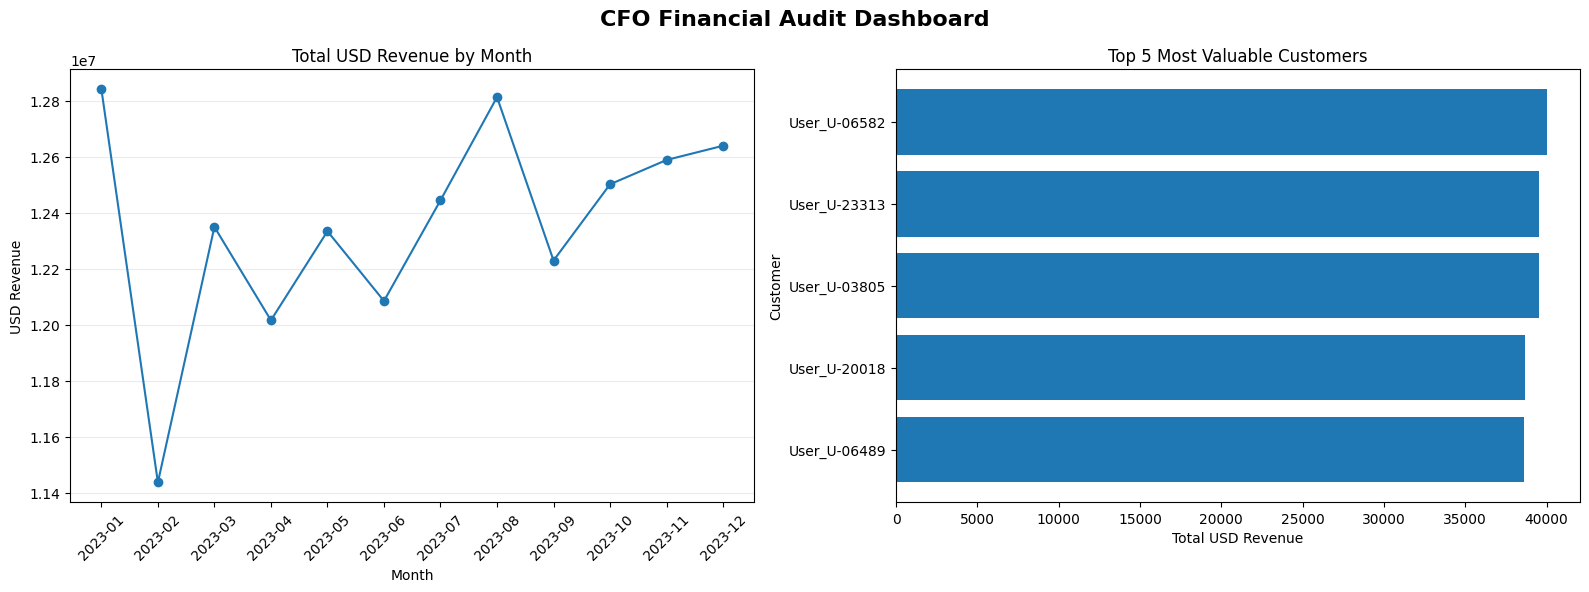

Monthly revenue summary:


,Month,USD_Revenue
0,2023-01,12841761.378267
1,2023-02,11436130.89548
2,2023-03,12348931.839154
3,2023-04,12015376.188684
4,2023-05,12333644.45212
5,2023-06,12084355.815201
6,2023-07,12444163.579437
7,2023-08,12812730.66336
8,2023-09,12228952.048007
9,2023-10,12501330.356145


Top 5 customers:


,User_ID,Customer_Name,USD_Revenue
3613,U-06582,User_U-06582,40050.988262
12937,U-23313,User_U-23313,39555.806629
2078,U-03805,User_U-03805,39529.945085
11066,U-20018,User_U-20018,38649.965242
3553,U-06489,User_U-06489,38629.142146


Dashboard saved: cfo_dashboard.png


In [5]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================
monthly_revenue = (
    df_final.groupby('Month', as_index=False)['USD_Revenue']
    .sum()
    .sort_values('Month')
)

top_customers = (
    df_final.groupby(['User_ID', 'Customer_Name'], as_index=False)['USD_Revenue']
    .sum()
    .sort_values('USD_Revenue', ascending=False)
    .head(5)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Monthly revenue
axes[0].plot(
    monthly_revenue['Month'],
    monthly_revenue['USD_Revenue'],
    marker='o'
)
axes[0].set_title('Total USD Revenue by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('USD Revenue')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)

# Chart 2: Top five customers
top_plot = top_customers.sort_values('USD_Revenue')
axes[1].barh(
    top_plot['Customer_Name'],
    top_plot['USD_Revenue']
)
axes[1].set_title('Top 5 Most Valuable Customers')
axes[1].set_xlabel('Total USD Revenue')
axes[1].set_ylabel('Customer')

fig.suptitle('CFO Financial Audit Dashboard', fontsize=16, fontweight='bold')
fig.tight_layout()
fig.savefig(DASHBOARD_PATH, dpi=180, bbox_inches='tight')
plt.show()

print('Monthly revenue summary:')
display(monthly_revenue)
print('Top 5 customers:')
display(top_customers)
print(f"Dashboard saved: {DASHBOARD_PATH.name}")

## Validation Checklist

- **Advanced SQL:** `ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC)` isolates the latest user status before filtering to `Active`.
- **Regex extraction:** successful transactions are parsed from the raw log strings using vectorized `Series.str.extract()`.
- **Error handling:** log rows containing `ERROR` are excluded before transaction extraction.
- **Temporal reconciliation:** the FX table is sorted and forward-filled so missing market dates inherit the most recent available rate.
- **Data integration:** transactions are joined to FX by `Date` and to the latest active customer records by `User_ID`.
- **Revenue calculation:** `USD_Revenue = Euro_Value × EUR_to_USD`.
- **Efficiency:** the pipeline uses vectorized Pandas operations and SQL window functions; no Pandas `for`/`iterrows()` loops are used.
- **Outputs:** `df_final.csv` and `cfo_dashboard.png` are generated automatically in the project folder.